In [1]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import matplotlib.cm as cm
from matplotlib.cm import ScalarMappable


import scipy
import numpy as np
import pandas as pd

from pathlib import Path
import soundfile as sf
from tqdm import tqdm
from sklearn.cluster import KMeans
import scipy.signal as signal
import scipy.special as special

import matplotlib.lines as mlines

In [2]:
import sys

# append the path of the
# parent directory
sys.path.append('..')
sys.path.append('../src/')
sys.path.append('../src/models/bat_call_detector/batdetect2/')

import src.batdt2_pipeline as batdetect2_pipeline
from pipeline import pipeline
from cfg import get_config

import bout_clustering as clstr

In [ ]:
C = 343 # m/s speed of sound in air
FS = 250000
SNR_CALC_LENGTH = 0.030
SNR_OFFSET_BEFORE_CALL = 0.015
TIME_PAD_FOR_ECHO = 0.002
CORR_LENGTH = 0.025
SELECTED_CHANNEL_FOR_REF = 7
NUM_CHANNELS_TOTAL = 8
FILE_DURATION = 120
HOUR_TAG = 'hour_0'
ZMAG_REF_TO_6 = 46.5625
ZMAG_REF_TO_1 = 35.5
XMAG_REF_TO_1 = 17.7
YMAG_REF_TO_6 = 21
YMAG_REF_TO_1 = 37.5
A_LOCS_MAT = np.array([[-XMAG_REF_TO_1, YMAG_REF_TO_1, -ZMAG_REF_TO_1],
                    [-XMAG_REF_TO_1, -YMAG_REF_TO_1, -ZMAG_REF_TO_1],
                    [-XMAG_REF_TO_1, YMAG_REF_TO_1, 0],
                    [-XMAG_REF_TO_1, -YMAG_REF_TO_1, 0],
                    [-XMAG_REF_TO_1, YMAG_REF_TO_6, ZMAG_REF_TO_6],
                    [-XMAG_REF_TO_1, -YMAG_REF_TO_6, ZMAG_REF_TO_6],
                    [0, 0, -ZMAG_REF_TO_1],
                    [0, 0, 0]])

In [ ]:
import UBNA_localize_process_GCC as localize

In [ ]:
def plot_snr_and_mic_labels(x_axis, y_axis):
    for i in np.linspace(0, x_axis.shape[0]-1, 11).astype(int):
        scale = 0.3
        t_x, t_y = x_axis[i]+scale, y_axis[i]+scale
        plt.text(x=t_x, y=t_y, s=f'det{round(i, 1)}', fontsize=14)

In [6]:
%matplotlib inline

microphones_used = np.array([1, 3, 4, 5, 6, 7, 8])
ind_of_selected_channel = np.where(microphones_used==(SELECTED_CHANNEL_FOR_REF+1))[0]
SELECTED_MIC_FOR_REF = microphones_used[ind_of_selected_channel]
non_ref_microphones_used = microphones_used[microphones_used!=SELECTED_MIC_FOR_REF]
num_good_channels = microphones_used.shape[0]
num_nonref_channels = num_good_channels-1

file_dir = Path('/Volumes/Elements/UBNA_array_tests/mic_array_test_20241010/inUBNA/array')
site_key = 'Telephone'
freq_key = ''

data_params = dict()
data_params['site_tag'] = site_key
data_params['type_tag'] = freq_key
data_params['detector_tag'] = 'bd2'
data_params['assembly_type'] = 'kmeans'
file_paths = dict()
file_paths["SITE_folder"] = f'/Users/adityakrishna/duty-cycle-investigation/data_old/2022_detector_summaries/{data_params["site_tag"]}'
file_paths["detector_TYPE_SITE_YEAR"] = f'{data_params["detector_tag"]}__{data_params["type_tag"]}{data_params["site_tag"]}_2022_{data_params["assembly_type"]}'
location_df = pd.read_csv(f'{file_paths["SITE_folder"]}/{file_paths["detector_TYPE_SITE_YEAR"]}.csv', index_col=0, low_memory=False)
bout_params = clstr.get_bout_params_from_location(location_df, data_params)
bout_params

{'site_key': 'Telephone',
 'HF_bci': 4640.588823870457,
 'LF_bci': 5004.35931804827}

In [7]:
COLOR_MAP_FOR_TRAJ = {0:cm.Blues, 1:cm.Reds, 2:cm.Greens}

In [19]:
MIC_MARKER_THICKNESS = 2
POINT_SIZE = 75

In [20]:
def plot_three_plane_trajectories(ax1, ax2, ax3, dets, good_bucket, bucket, mic_locs, color_ind):
    ax1.plot(good_bucket[0,:], good_bucket[1,:], alpha=0.4, linewidth=2, color='k')
    ax1.scatter(x=mic_locs[:,0], y=mic_locs[:,1], zorder=2, s=POINT_SIZE, 
                marker='x', linewidths=MIC_MARKER_THICKNESS, color='k')

    ax2.plot(good_bucket[1,:], good_bucket[2,:], alpha=0.4, linewidth=2, color='k')
    ax2.scatter(x=mic_locs[:,1], y=mic_locs[:,2], zorder=2, s=POINT_SIZE, 
                marker='x', linewidths=MIC_MARKER_THICKNESS, color='k')

    ax3.plot(good_bucket[0,:], good_bucket[2,:], alpha=0.4, linewidth=2, color='k')
    ax3.scatter(x=mic_locs[:,0], y=mic_locs[:,2], zorder=2, s=POINT_SIZE, 
                marker='x', linewidths=MIC_MARKER_THICKNESS, color='k')

    norm = plt.Normalize(vmin=min(dets['start_time']), vmax=max(dets['start_time']))
    for i in range(good_bucket.shape[1]):
        det = dets.iloc[i]
        line_color = COLOR_MAP_FOR_TRAJ[color_ind](norm(det['start_time']))
        ax1.scatter(bucket[0,i], bucket[1,i], color=line_color, edgecolor='k', alpha=1, s=POINT_SIZE, zorder=3)
        ax2.scatter(bucket[1,i], bucket[2,i], color=line_color, edgecolor='k', alpha=1, s=POINT_SIZE, zorder=3)
        ax3.scatter(bucket[0,i], bucket[2,i], color=line_color, edgecolor='k', alpha=1, s=POINT_SIZE, zorder=3)

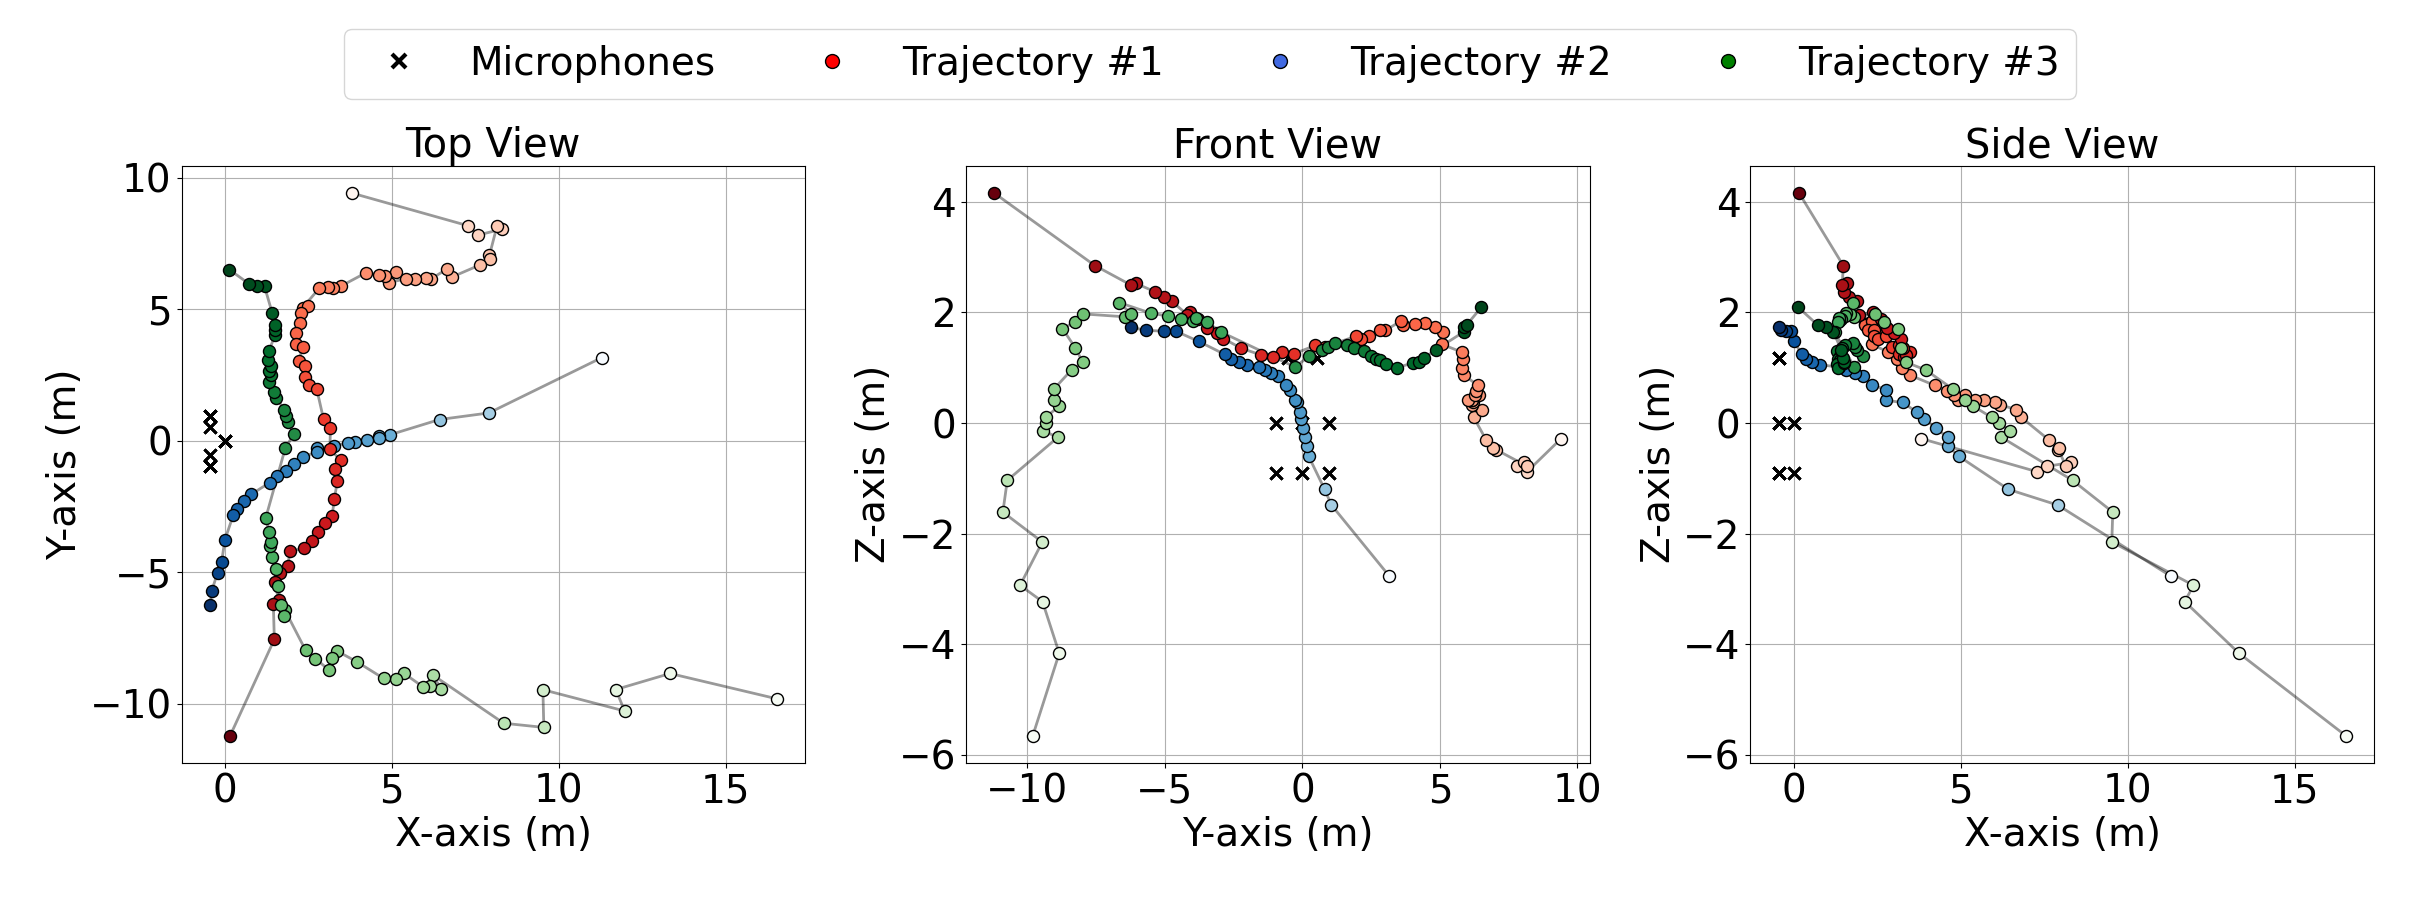

In [21]:
%matplotlib inline

fig, (ax1, ax2, ax3) = plt.subplots(1,3, figsize=(24, 8))
plt.rcParams.update({'font.size':24})
for ind, file_offset in enumerate(np.array([240, 1800, 3000])):
    FILE_TIME_TAG = f'{int(file_offset)}to{int(file_offset+FILE_DURATION)}'
    dir_name = f'{HOUR_TAG}_{FILE_TIME_TAG}'
    write_dir = file_dir / dir_name

    channel_dets = localize.get_dets_observed_from_all_channels(microphones_used, file_dir, file_offset)

    channel_dets.sort_values(by='start_time', inplace=True)
    channel_dets.reset_index(drop=True, inplace=True)
    removed_overlaps = localize.remove_overlapping_events(channel_dets, time_threshold=0.01)
    snr_thresh_dets = removed_overlaps[removed_overlaps['SNR']>=15].copy()
    if len(snr_thresh_dets)>0:
        tagged_dets = clstr.classify_bouts_in_detector_preds_for_freqgroups(snr_thresh_dets, bout_params)
        bout_metrics = clstr.construct_bout_metrics_from_location_df_for_freqgroups(tagged_dets)
        write_file = write_dir / f'{HOUR_TAG}_channel{SELECTED_CHANNEL_FOR_REF}_{FILE_TIME_TAG}.WAV'

        sorted_bout_metrics = bout_metrics.sort_values('bout_duration_in_secs', ascending=False)
        bout = sorted_bout_metrics.iloc[0]
        start = max(0, bout['start_time'] - file_offset - 1.5*bout['bout_duration_in_secs'])
        length = min(bout['bout_duration_in_secs']*3, (FILE_DURATION) - start)
        if length>5:
            plot_channel_dets = channel_dets.loc[(channel_dets['start_time']>=(file_offset+start))&(channel_dets['end_time']<=(file_offset+start+length))]
            plot_dets = removed_overlaps.loc[(removed_overlaps['start_time']>=(file_offset+start))&(removed_overlaps['end_time']<=(file_offset+start+length))]

            if len(plot_dets[plot_dets['SNR']>=15])>=0:
                set_for_tdoa = plot_dets[plot_dets['SNR']>=0].reset_index(drop=True).copy()
                # localize.plot_audio_bout(write_file, SELECTED_CHANNEL_FOR_REF, start, length, file_offset, plot_channel_dets, set_for_tdoa)

                calls_for_tdoa, call_voltage_rms, snr_facs_for_tdoa, det_durs_for_tdoa = localize.find_relevant_tdoa_arrays(set_for_tdoa, microphones_used, file_offset, write_dir)
                t_delay_wrt_selected_channel = localize.find_d_mics_to_ref_using_GCC(set_for_tdoa, microphones_used, calls_for_tdoa, snr_facs_for_tdoa, det_durs_for_tdoa)
                d_mics_to_ref_meters, A_locs_mat_tdoa_inches = localize.get_d_mics_with_mic_locs(microphones_used, t_delay_wrt_selected_channel, SELECTED_CHANNEL_FOR_REF)
                A_locs_mat_tdoa_meters = A_locs_mat_tdoa_inches * (254/10000)

                source_points = localize.assemble_source_points_in_meters(d_mics_to_ref_meters, microphones_used, A_locs_mat_tdoa_meters)

                e1 = -1.4
                e2 = 0
                a = 2.4
                b = 3.0

                source_x_coords = source_points[0,:]
                source_y_coords = source_points[1,:]
                distance_of_points_from_ellipse = (((source_x_coords - e1) / a)**2) + (((source_y_coords - e2) / b)**2)
                dets_outside_unit_circle = set_for_tdoa[(distance_of_points_from_ellipse>1)&~(source_x_coords<-3)]
                src_points_outside_unit_circle = source_points[:,(distance_of_points_from_ellipse>1)&~(source_x_coords<-3)]

                speed_threshold = 6
                dist_travel_per_point = ((src_points_outside_unit_circle[:,1:] - src_points_outside_unit_circle[:,:-1])**2)[:3,:].sum(axis=0)
                time_between_points = (dets_outside_unit_circle['end_time'][1:].values - dets_outside_unit_circle['start_time'][:-1].values)
                speed_between_points = dist_travel_per_point / time_between_points
                valid_dets_outside_unit_circle = dets_outside_unit_circle[np.concatenate([[speed_threshold], speed_between_points])<speed_threshold]
                valid_speed_src_points_outside_unit_circle = src_points_outside_unit_circle[:,np.concatenate([[speed_threshold], speed_between_points])<speed_threshold]

                plot_three_plane_trajectories(ax1, ax2, ax3, valid_dets_outside_unit_circle, 
                                              valid_speed_src_points_outside_unit_circle, 
                                            valid_speed_src_points_outside_unit_circle, 
                                            (A_LOCS_MAT * (254/10000)), ind)

ax1.scatter(x=0, y=0, s=POINT_SIZE, zorder=2, marker='x', 
            linewidths=MIC_MARKER_THICKNESS, color='k', label='Microphones')
ax2.scatter(x=0, y=0, s=POINT_SIZE, zorder=2, marker='x', 
            linewidths=MIC_MARKER_THICKNESS, color='k', label='Microphones')
ax3.scatter(x=0, y=0, s=POINT_SIZE, zorder=2, marker='x', 
            linewidths=MIC_MARKER_THICKNESS, color='k', label='Microphones')

ax1.set_title(f'Top View')
ax1.grid(which='both')
ax1.set_xlabel('X-axis (m)')
ax1.set_ylabel('Y-axis (m)')

ax2.set_title('Front View')
ax2.grid(which='both')
ax2.set_xlabel('Y-axis (m)')
ax2.set_ylabel('Z-axis (m)')

ax3.set_title('Side View')
ax3.grid(which='both')
ax3.set_xlabel('X-axis (m)')
ax3.set_ylabel('Z-axis (m)')
fig.tight_layout()

# # Add legend
legend_ax = fig.add_axes([0.0, 0.0, 1.0, 1.10])
legend_ax.axis('off')

mic_handle = mlines.Line2D([], [],
    marker='x', 
    linestyle='None', 
    markersize=POINT_SIZE/7.5, 
    color='k',        
    markeredgewidth=MIC_MARKER_THICKNESS+1, 
    label='Microphones'
)

traj1_handle = mlines.Line2D([], [],
    marker='o', 
    linestyle='None', 
    markersize=POINT_SIZE/7.5, 
    markerfacecolor='red',
    markeredgecolor='k',
    markeredgewidth=1,
    label='Trajectory #1'
)

traj2_handle = mlines.Line2D([], [],
    marker='o', 
    linestyle='None', 
    markersize=POINT_SIZE/7.5, 
    markerfacecolor='royalblue',
    markeredgecolor='k',
    markeredgewidth=1,
    label='Trajectory #2'
)

traj3_handle = mlines.Line2D([], [],
    marker='o', 
    linestyle='None', 
    markersize=POINT_SIZE/7.5, 
    markerfacecolor='green',
    markeredgecolor='k',
    markeredgewidth=1,
    label='Trajectory #3'
)

# Then wherever you create the legend:
legend_ax.legend(handles=[mic_handle,
                          traj1_handle,
                          traj2_handle,
                          traj3_handle],
                 fontsize=plt.rcParams['font.size']+4,
                 ncol=4,
                 loc='upper center')

plt.show()

In [26]:
MIC_MARKER_THICKNESS = 3
POINT_SIZE = 100

In [27]:
def plot_three_plane_trajectories(ax1, ax2, ax3, dets, good_bucket, bucket, mic_locs, color_ind):
    ax1.plot(good_bucket[0,:], good_bucket[1,:], alpha=0.4, linewidth=2, color='k')
    ax1.scatter(x=mic_locs[:,0], y=mic_locs[:,1], zorder=2, s=POINT_SIZE, 
                marker='x', linewidths=MIC_MARKER_THICKNESS, color='k')

    ax2.plot(good_bucket[1,:], good_bucket[2,:], alpha=0.4, linewidth=2, color='k')
    ax2.scatter(x=mic_locs[:,1], y=mic_locs[:,2], zorder=2, s=POINT_SIZE, 
                marker='x', linewidths=MIC_MARKER_THICKNESS, color='k')

    ax3.plot(good_bucket[0,:], good_bucket[2,:], alpha=0.4, linewidth=2, color='k')
    ax3.scatter(x=mic_locs[:,0], y=mic_locs[:,2], zorder=2, s=POINT_SIZE, 
                marker='x', linewidths=MIC_MARKER_THICKNESS, color='k')

    norm = plt.Normalize(vmin=min(dets['start_time']), vmax=max(dets['start_time']))
    for i in range(good_bucket.shape[1]):
        det = dets.iloc[i]
        line_color = COLOR_MAP_FOR_TRAJ[color_ind](norm(det['start_time']))
        ax1.scatter(bucket[0,i], bucket[1,i], color=line_color, edgecolor='k', alpha=1, s=POINT_SIZE, zorder=3)
        ax2.scatter(bucket[1,i], bucket[2,i], color=line_color, edgecolor='k', alpha=1, s=POINT_SIZE, zorder=3)
        ax3.scatter(bucket[0,i], bucket[2,i], color=line_color, edgecolor='k', alpha=1, s=POINT_SIZE, zorder=3)

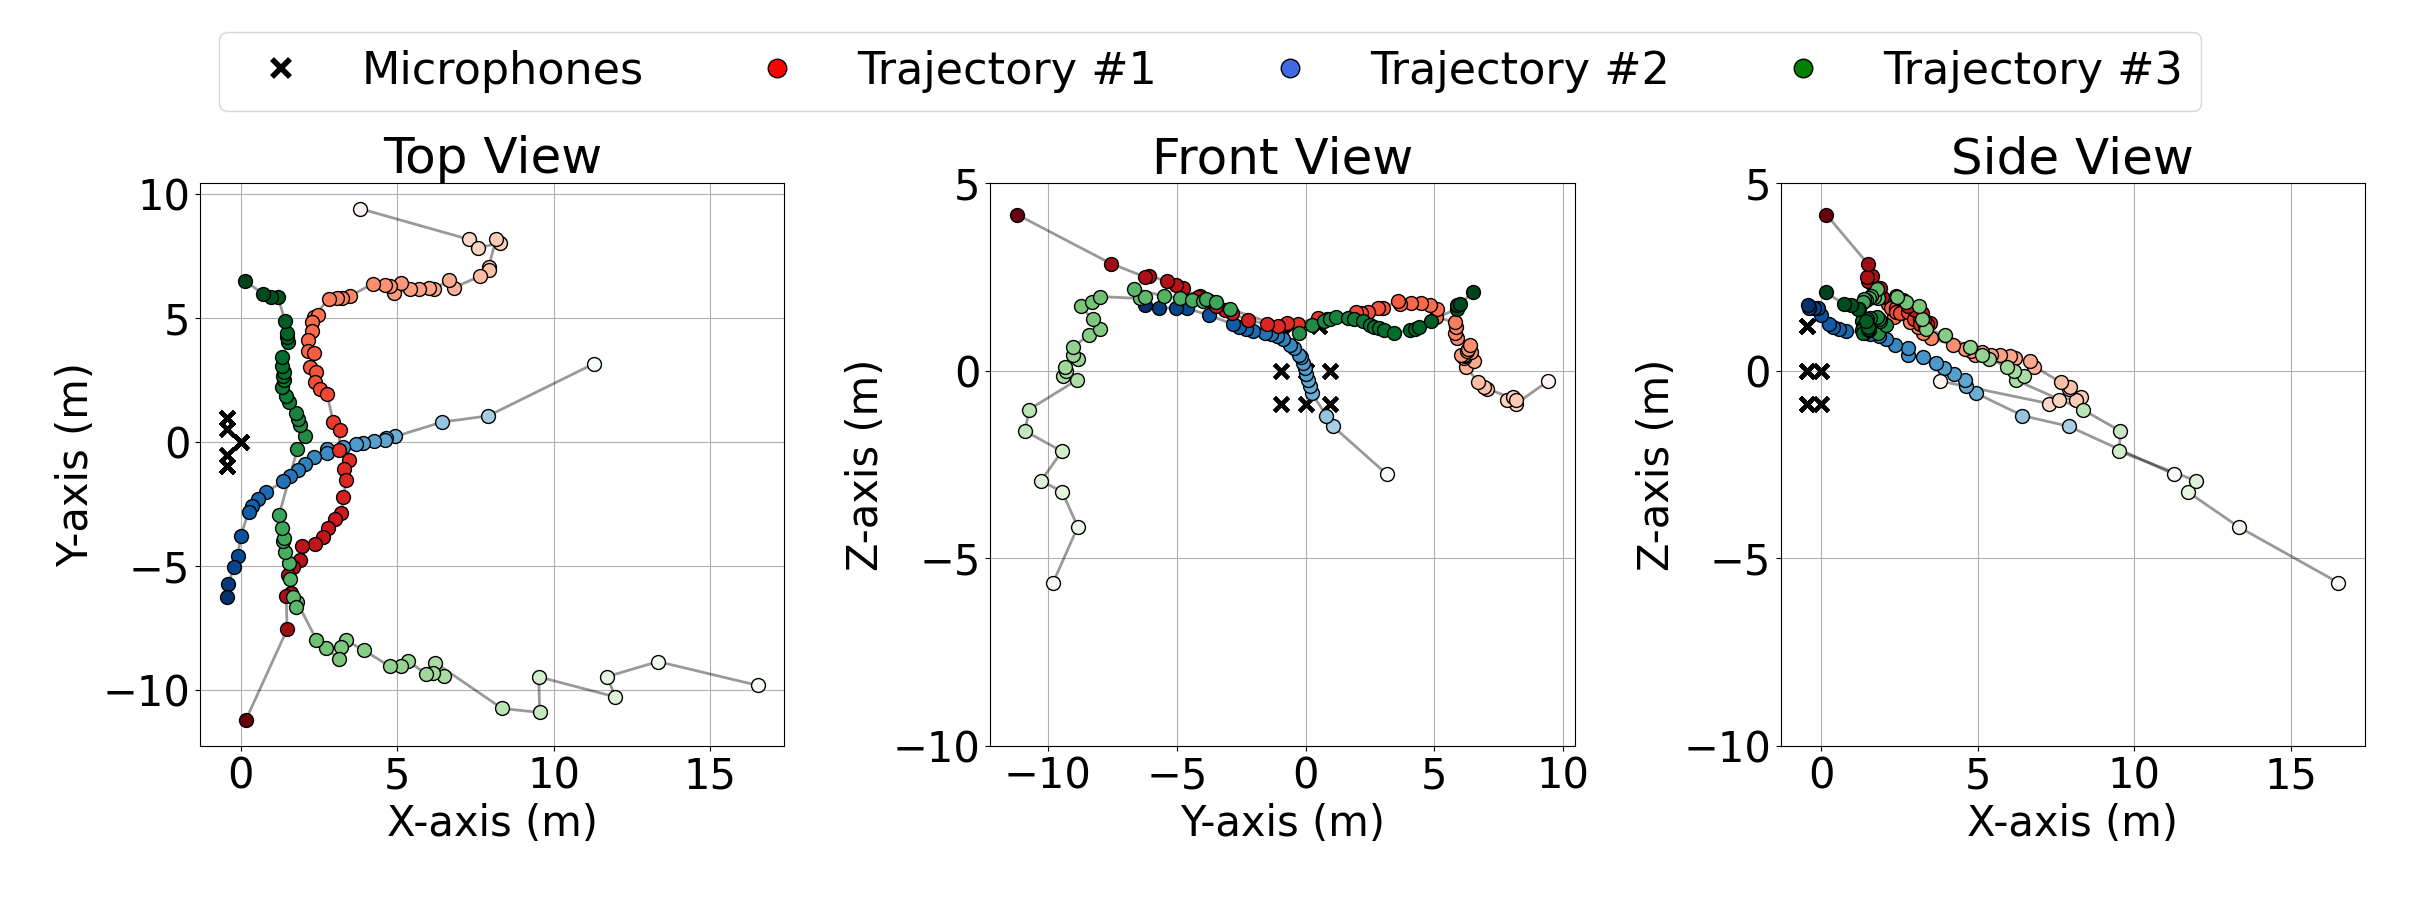

In [37]:
%matplotlib inline

fig, (ax1, ax2, ax3) = plt.subplots(1,3, figsize=(24, 8))
plt.rcParams.update({'font.size':30})
for ind, file_offset in enumerate(np.array([240, 1800, 3000])):
    FILE_TIME_TAG = f'{int(file_offset)}to{int(file_offset+FILE_DURATION)}'
    dir_name = f'{HOUR_TAG}_{FILE_TIME_TAG}'
    write_dir = file_dir / dir_name

    channel_dets = localize.get_dets_observed_from_all_channels(microphones_used, file_dir, file_offset)

    channel_dets.sort_values(by='start_time', inplace=True)
    channel_dets.reset_index(drop=True, inplace=True)
    removed_overlaps = localize.remove_overlapping_events(channel_dets, time_threshold=0.01)
    snr_thresh_dets = removed_overlaps[removed_overlaps['SNR']>=15].copy()
    if len(snr_thresh_dets)>0:
        tagged_dets = clstr.classify_bouts_in_detector_preds_for_freqgroups(snr_thresh_dets, bout_params)
        bout_metrics = clstr.construct_bout_metrics_from_location_df_for_freqgroups(tagged_dets)
        write_file = write_dir / f'{HOUR_TAG}_channel{SELECTED_CHANNEL_FOR_REF}_{FILE_TIME_TAG}.WAV'

        sorted_bout_metrics = bout_metrics.sort_values('bout_duration_in_secs', ascending=False)
        bout = sorted_bout_metrics.iloc[0]
        start = max(0, bout['start_time'] - file_offset - 1.5*bout['bout_duration_in_secs'])
        length = min(bout['bout_duration_in_secs']*3, (FILE_DURATION) - start)
        if length>5:
            plot_channel_dets = channel_dets.loc[(channel_dets['start_time']>=(file_offset+start))&(channel_dets['end_time']<=(file_offset+start+length))]
            plot_dets = removed_overlaps.loc[(removed_overlaps['start_time']>=(file_offset+start))&(removed_overlaps['end_time']<=(file_offset+start+length))]

            if len(plot_dets[plot_dets['SNR']>=15])>=0:
                set_for_tdoa = plot_dets[plot_dets['SNR']>=0].reset_index(drop=True).copy()
                # localize.plot_audio_bout(write_file, SELECTED_CHANNEL_FOR_REF, start, length, file_offset, plot_channel_dets, set_for_tdoa)

                calls_for_tdoa, call_voltage_rms, snr_facs_for_tdoa, det_durs_for_tdoa = localize.find_relevant_tdoa_arrays(set_for_tdoa, microphones_used, file_offset, write_dir)
                t_delay_wrt_selected_channel = localize.find_d_mics_to_ref_using_GCC(set_for_tdoa, microphones_used, calls_for_tdoa, snr_facs_for_tdoa, det_durs_for_tdoa)
                d_mics_to_ref_meters, A_locs_mat_tdoa_inches = localize.get_d_mics_with_mic_locs(microphones_used, t_delay_wrt_selected_channel, SELECTED_CHANNEL_FOR_REF)
                A_locs_mat_tdoa_meters = A_locs_mat_tdoa_inches * (254/10000)

                source_points = localize.assemble_source_points_in_meters(d_mics_to_ref_meters, microphones_used, A_locs_mat_tdoa_meters)

                e1 = -1.4
                e2 = 0
                a = 2.4
                b = 3.0

                source_x_coords = source_points[0,:]
                source_y_coords = source_points[1,:]
                distance_of_points_from_ellipse = (((source_x_coords - e1) / a)**2) + (((source_y_coords - e2) / b)**2)
                dets_outside_unit_circle = set_for_tdoa[(distance_of_points_from_ellipse>1)&~(source_x_coords<-3)]
                src_points_outside_unit_circle = source_points[:,(distance_of_points_from_ellipse>1)&~(source_x_coords<-3)]

                speed_threshold = 6
                dist_travel_per_point = ((src_points_outside_unit_circle[:,1:] - src_points_outside_unit_circle[:,:-1])**2)[:3,:].sum(axis=0)
                time_between_points = (dets_outside_unit_circle['end_time'][1:].values - dets_outside_unit_circle['start_time'][:-1].values)
                speed_between_points = dist_travel_per_point / time_between_points
                valid_dets_outside_unit_circle = dets_outside_unit_circle[np.concatenate([[speed_threshold], speed_between_points])<speed_threshold]
                valid_speed_src_points_outside_unit_circle = src_points_outside_unit_circle[:,np.concatenate([[speed_threshold], speed_between_points])<speed_threshold]

                plot_three_plane_trajectories(ax1, ax2, ax3, valid_dets_outside_unit_circle, 
                                              valid_speed_src_points_outside_unit_circle, 
                                            valid_speed_src_points_outside_unit_circle, 
                                            (A_LOCS_MAT * (254/10000)), ind)

ax1.scatter(x=0, y=0, s=POINT_SIZE, zorder=2, marker='x', 
            linewidths=MIC_MARKER_THICKNESS, color='k', label='Microphones')
ax2.scatter(x=0, y=0, s=POINT_SIZE, zorder=2, marker='x', 
            linewidths=MIC_MARKER_THICKNESS, color='k', label='Microphones')
ax3.scatter(x=0, y=0, s=POINT_SIZE, zorder=2, marker='x', 
            linewidths=MIC_MARKER_THICKNESS, color='k', label='Microphones')

ax1.set_title(f'Top View')
ax1.grid(which='both')
ax1.set_xlabel('X-axis (m)')
ax1.set_ylabel('Y-axis (m)')

ax2.set_title('Front View')
ax2.grid(which='both')
ax2.set_xlabel('Y-axis (m)')
ax2.set_ylabel('Z-axis (m)')
ax2.set_yticks(np.arange(-10, 6, 5))
ax2.set_xticks(np.arange(-10, 11, 5))

ax3.set_title('Side View')
ax3.grid(which='both')
ax3.set_xlabel('X-axis (m)')
ax3.set_ylabel('Z-axis (m)')
ax3.set_yticks(np.arange(-10, 6, 5))
fig.tight_layout()

# # Add legend
legend_ax = fig.add_axes([0.0, 0.0, 1.0, 1.10])
legend_ax.axis('off')

mic_handle = mlines.Line2D([], [],
    marker='x', 
    linestyle='None', 
    markersize=POINT_SIZE/7.5, 
    color='k',        
    markeredgewidth=MIC_MARKER_THICKNESS+1, 
    label='Microphones'
)

traj1_handle = mlines.Line2D([], [],
    marker='o', 
    linestyle='None', 
    markersize=POINT_SIZE/7.5, 
    markerfacecolor='red',
    markeredgecolor='k',
    markeredgewidth=1,
    label='Trajectory #1'
)

traj2_handle = mlines.Line2D([], [],
    marker='o', 
    linestyle='None', 
    markersize=POINT_SIZE/7.5, 
    markerfacecolor='royalblue',
    markeredgecolor='k',
    markeredgewidth=1,
    label='Trajectory #2'
)

traj3_handle = mlines.Line2D([], [],
    marker='o', 
    linestyle='None', 
    markersize=POINT_SIZE/7.5, 
    markerfacecolor='green',
    markeredgecolor='k',
    markeredgewidth=1,
    label='Trajectory #3'
)

# Then wherever you create the legend:
legend_ax.legend(handles=[mic_handle,
                          traj1_handle,
                          traj2_handle,
                          traj3_handle],
                 fontsize=plt.rcParams['font.size']+2,
                 ncol=4,
                 loc='upper center')

plt.show()